# 06 — Pilot: peptide function-similarity (pairwise AUROC)

A model-free complement to the Notebook 05 probe: instead of asking
"can a classifier recover function from an embedding", this asks
"do two peptides from same-function proteins land closer together
in embedding space than two peptides from different-function
proteins" — no classifier fitted at all, just raw geometry.

**Setup:** digest a handful of well-annotated bacterial proteomes
(`configs/pilot_organisms.yaml`: *E. coli*, *B. subtilis*,
*M. tuberculosis*, *P. aeruginosa*), embed the peptides with the
small ESM2 checkpoint, and score every cross-protein peptide pair by
cosine similarity. "Function" = full EC number (not just the
top-level class used in Notebooks 04-05) — a much more specific
"same enzymatic activity" label, chosen so cross-*species* pairs
(e.g. the same conserved enzyme in *E. coli* and *M. tuberculosis*)
count as "same function" too.

**Metric:** AUROC on same-function-vs-different-function pairs, labelled 1 if the two source proteins share an EC number, 0 otherwise. This is exactly the Mann-Whitney U statistic — the probability a random same-function pair scores higher than a random different-function pair. Same-function pairs are a small minority of all pairs, so AUROC alone is optimistic — average precision and precision@k are reported alongside it.

Kernel: **Python (plm-benchmark)** (the repo `.venv`).

In [1]:
import sys
from pathlib import Path

# notebooks/ lives one level below the repo root
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print("repo root:", REPO_ROOT)

repo root: /Users/annaquaglieri/Projects/ProteinPrediction


## Fetch the pilot proteomes

Same skip-if-present pattern as Notebooks 01/04, looped over
`configs/pilot_organisms.yaml`.

In [2]:
import yaml

from plm_benchmark.data_io import fetch_uniprot_proteome, load_fasta
from plm_benchmark.labels import fetch_ec_labels, load_ec_labels

pilot_config = yaml.safe_load((REPO_ROOT / "configs" / "pilot_organisms.yaml").read_text())

for org in pilot_config["organisms"]:
    proteome_id = org["uniprot_proteome_id"]
    fasta_path = REPO_ROOT / "data" / "raw" / f"{proteome_id}.fasta"
    ec_path = REPO_ROOT / "data" / "raw" / f"{proteome_id}_ec_labels.tsv"
    if not fasta_path.exists():
        fetch_uniprot_proteome(proteome_id, fasta_path, reviewed_only=org["reviewed_only"])
    if not ec_path.exists():
        fetch_ec_labels(proteome_id, ec_path, reviewed_only=org["reviewed_only"])
    print("ready:", org["organism"])

ready: Escherichia coli str. K-12 substr. MG1655
ready: Bacillus subtilis (strain 168)
ready: Mycobacterium tuberculosis (strain ATCC 25618 / H37Rv)
ready: Pseudomonas aeruginosa (strain ATCC 15692 / PAO1)


## Digest each proteome, cap peptides per protein

Same enzyme/length settings as Notebooks 02-03-05
(`configs/enzymes.yaml`). Peptides inherit their parent protein's
**full** EC number (not top-level class) — the specific label this
pilot uses for "same function".

`pair_eval.sample_peptides_per_protein` caps how many peptides come
from any one protein (default 2 here) — without this, a protein
digested with missed cleavages contributes dozens of overlapping
peptides, which would both blow up the O(n²) pair count and bias
the pair pool toward whichever proteins happen to be long.

In [3]:
import numpy as np
import pandas as pd

from plm_benchmark.evaluate import build_fragment_dataset
from plm_benchmark.pair_eval import sample_peptides_per_protein

digest_config = yaml.safe_load((REPO_ROOT / "configs" / "enzymes.yaml").read_text())
MAX_PEPTIDES_PER_PROTEIN = 2
rng = np.random.default_rng(0)

per_organism_peptides = []
for org in pilot_config["organisms"]:
    proteome_id = org["uniprot_proteome_id"]
    sequences = load_fasta(REPO_ROOT / "data" / "raw" / f"{proteome_id}.fasta")
    ec_full = load_ec_labels(REPO_ROOT / "data" / "raw" / f"{proteome_id}_ec_labels.tsv", level="full")

    labeled_proteins = {
        protein_id: seq
        for protein_id, seq in sequences.items()
        if protein_id.split("|")[1] in ec_full
    }
    peptide_df = build_fragment_dataset(
        labeled_proteins,
        enzyme=digest_config["default_enzyme"],
        missed_cleavages=max(digest_config["missed_cleavages"]),
        min_length=digest_config["min_length"],
        max_length=digest_config["max_length"],
    )
    peptide_df["ec_full"] = peptide_df["protein_id"].map(lambda pid: ec_full[pid.split("|")[1]])
    peptide_df["organism"] = org["organism"]
    peptide_df = sample_peptides_per_protein(peptide_df, max_per_protein=MAX_PEPTIDES_PER_PROTEIN, rng=rng)

    print(f"{org['organism']:55s} proteins={len(labeled_proteins):5d} peptides(capped)={len(peptide_df):6d}")
    per_organism_peptides.append(peptide_df)

peptide_df = pd.concat(per_organism_peptides, ignore_index=True)
print(f"\ntotal peptides across {len(pilot_config['organisms'])} organisms: {len(peptide_df):,}")

Escherichia coli str. K-12 substr. MG1655               proteins= 1740 peptides(capped)=  3480
Bacillus subtilis (strain 168)                          proteins= 1557 peptides(capped)=  3114
Mycobacterium tuberculosis (strain ATCC 25618 / H37Rv)  proteins= 1217 peptides(capped)=  2432
Pseudomonas aeruginosa (strain ATCC 15692 / PAO1)       proteins=  889 peptides(capped)=  1778

total peptides across 4 organisms: 10,804


## Embed the peptides

~10.8k peptides — a couple of minutes on CPU with the small ESM2
checkpoint (much cheaper than Notebook 05's ~138k, since capping
peptides/protein controls the O(n²) pair count that comes next).

In [4]:
from plm_benchmark.embed import DEFAULT_MODEL, embed_sequences

embeddings = embed_sequences(peptide_df["peptide"].tolist(), model_name=DEFAULT_MODEL)
print("embeddings shape:", embeddings.shape)

/Users/annaquaglieri/Projects/ProteinPrediction/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 198/198 [00:00<00:00, 11663.28it/s]
[transformers] EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the c

embeddings shape: (10804, 480)


## Build cross-protein pairs and score by cosine similarity

`pair_eval.build_cross_protein_pairs` takes every i<j pair of
peptides from *different* proteins (same-protein pairs are excluded
— two peptides from one protein are often overlapping substrings,
which would trivially look similar regardless of any real
functional signal) and labels each pair 1 if the two parent
proteins share the same full EC number, 0 otherwise.

In [5]:
from plm_benchmark.pair_eval import build_cross_protein_pairs, pairwise_cosine_similarity

protein_ids = peptide_df["protein_id"].to_numpy()
function_labels = peptide_df["ec_full"].to_numpy()
i_idx, j_idx, same_function = build_cross_protein_pairs(protein_ids, function_labels)

similarity_matrix = pairwise_cosine_similarity(embeddings.astype(np.float32))
similarity = similarity_matrix[i_idx, j_idx]

print(f"pairs: {len(similarity):,} (same-function: {same_function.sum():,}, "
      f"prevalence: {same_function.mean():.4%})")

pairs: 58,352,405 (same-function: 189,350, prevalence: 0.3245%)


## AUROC, average precision, precision@k

`pair_eval.evaluate_pairs` treats cosine similarity as a classifier
score for the "same function" label and reports all three.

In [6]:
from plm_benchmark.pair_eval import evaluate_pairs

metrics = evaluate_pairs(similarity, same_function, k_values=(10, 50, 100, 500, 1000))
for key, value in metrics.items():
    print(f"{key}: {value}")

n_pairs: 58352405
n_same_function: 189350
prevalence: 0.003244939090342549
auroc: 0.4736196261136516
average_precision: 0.0030584438083353553
precision_at_k: {10: 0.1, 50: 0.06, 100: 0.04, 500: 0.016, 1000: 0.01}


## Figure: similarity distribution, ROC, PR

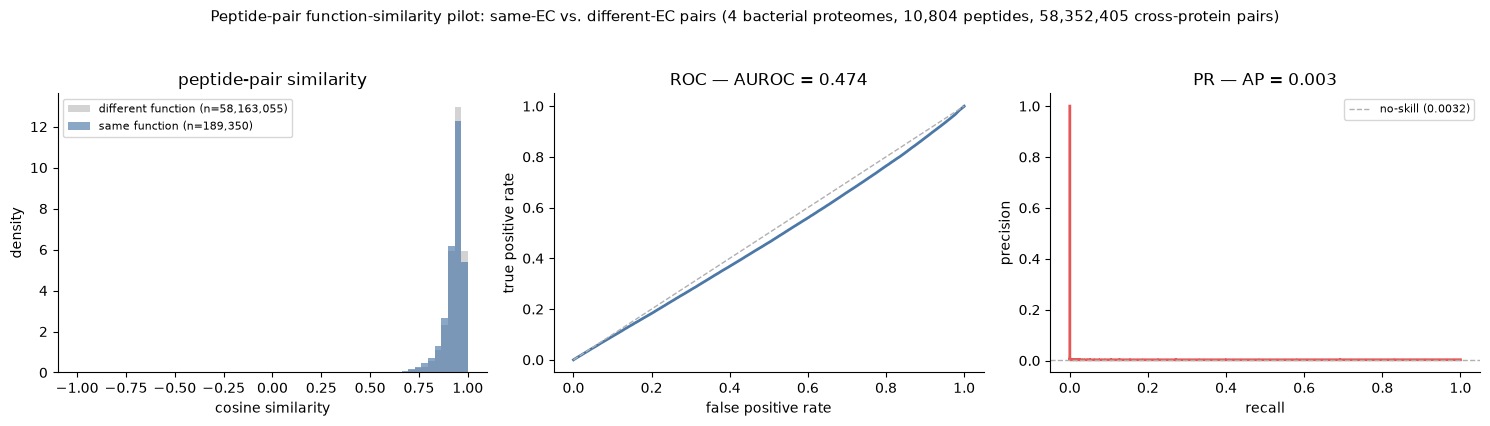

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))

ax = axes[0]
same_sim = similarity[same_function == 1]
diff_sim = similarity[same_function == 0]
diff_sample = diff_sim if len(diff_sim) <= 200_000 else rng.choice(diff_sim, 200_000, replace=False)
bins = np.linspace(-1, 1, 60)
ax.hist(diff_sample, bins=bins, density=True, alpha=0.55, color="#B0B0B0",
        label=f"different function (n={len(diff_sim):,})")
ax.hist(same_sim, bins=bins, density=True, alpha=0.65, color="#4C78A8",
        label=f"same function (n={len(same_sim):,})")
ax.set_xlabel("cosine similarity")
ax.set_ylabel("density")
ax.set_title("peptide-pair similarity")
ax.legend(fontsize=8, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)

ax = axes[1]
fpr, tpr, _ = roc_curve(same_function, similarity)
ax.plot(fpr, tpr, color="#4C78A8", lw=2)
ax.plot([0, 1], [0, 1], color="#B0B0B0", lw=1, linestyle="--")
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.set_title(f"ROC — AUROC = {metrics['auroc']:.3f}")
ax.spines[["top", "right"]].set_visible(False)

ax = axes[2]
precision, recall, _ = precision_recall_curve(same_function, similarity)
ax.plot(recall, precision, color="#E45756", lw=2)
ax.axhline(metrics["prevalence"], color="#B0B0B0", lw=1, linestyle="--",
           label=f"no-skill ({metrics['prevalence']:.4f})")
ax.set_xlabel("recall")
ax.set_ylabel("precision")
ax.set_title(f"PR — AP = {metrics['average_precision']:.3f}")
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "Peptide-pair function-similarity pilot: same-EC vs. different-EC pairs "
    f"(4 bacterial proteomes, {len(peptide_df):,} peptides, {len(similarity):,} cross-protein pairs)",
    fontsize=11,
)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(REPO_ROOT / "results" / "pilot_function_similarity.png", dpi=150)
plt.show()

## Reading the result

The similarity histogram is the important panel: same-function and
different-function pairs are almost completely overlapping, both
piled up in the 0.85-1.0 range. That's not "no signal" in the usual
sense — it's that *every* pair, related or not, looks highly similar
under mean-pooled cosine similarity. This is the well-known
**anisotropy** problem with contextual embeddings: mean-pooling
collapses sequences into a narrow cone of the embedding space rather
than spreading them out by content, which is exactly what erases the
separation AUROC is trying to measure.

That's consistent with — and mechanistically explains — Notebook
05's finding that probe accuracy collapses on short peptides: it's
not just that a *classifier* struggles on incomplete sequences, the
raw geometry itself barely separates function classes once you're
down to tryptic-peptide length, even with a model-free nearest-
neighbor-style test and even when "same function" is allowed to mean
the same enzyme *conserved across species*.

## Save

In [ ]:
processed_dir = REPO_ROOT / "data" / "processed"
results_dir = REPO_ROOT / "results"

np.save(processed_dir / "pilot_peptide_embeddings.npy", embeddings)
peptide_df.to_csv(processed_dir / "pilot_peptide_digest.csv", index=False)

precision_at_k_df = pd.DataFrame(
    [{"k": k, "precision_at_k": v} for k, v in metrics["precision_at_k"].items()]
)
precision_at_k_df.to_csv(results_dir / "pilot_precision_at_k.csv", index=False)

summary = {k: v for k, v in metrics.items() if k != "precision_at_k"}
pd.DataFrame([summary]).to_csv(results_dir / "pilot_summary_metrics.csv", index=False)
print("saved embeddings, digest table, and metrics")

## Next

- Try **CLS-token pooling** instead of mean pooling (`embed_sequences(..., pooling="cls")`)
  — mean pooling is a known driver of anisotropy; CLS or a
  whitening/standardization post-process often separates embedding
  spaces much better for retrieval-style tasks like this one.
- Try a **larger ESM2 checkpoint** — this pilot deliberately used the
  smallest (t12, 35M) for speed; more capacity may retain more
  function signal at short lengths.
- Restrict pairs to **within-organism only** vs. **cross-organism
  only** and compare AUROC between the two — tests whether any
  signal that does exist is really "function" or just "sequence
  homology within one genome".